# **Lab5.1 : CNN Feature maps**

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch import nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms


## Get VGG16 Pretrained model
Explore the VGG16 achitecture.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (18): ReLU(inplace=True)
    (19): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (20): ReLU(inplace=True)
    (21): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (22): ReLU(inplace=True)
    (23): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (24): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (25): ReLU(inplace=True)
    (26): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (27): ReLU(inplace=True)
    (28): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (29): ReLU(inplace=True)
    (30): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(7, 7))
  (classifier): Sequential(
    (0): Linear(in_features=25088, out_features=4096, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=4096, out_features=4096, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=4096, out_features=1000, bias=True)
  )
)
```

</details>


In [5]:
### START CODE HERE ###
vgg16 = models.vgg16(pretrained=True)
vgg16

### END CODE HERE ###

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Explore all layers in feature extractor part.
[Read more.](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.named_modules:~:text=named_modules(memo%3DNone%2C%20prefix%3D%27%27%2C%20remove_duplicate%3DTrue))


<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
-------------------
0:Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
1:ReLU(inplace=True)
-------------------
2:Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
3:ReLU(inplace=True)
-------------------
4:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
...
28:Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
29:ReLU(inplace=True)
-------------------
30:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
```

</details>


In [6]:
### START CODE HERE ###
for name, module in vgg16.named_children():
    print(module)

### END CODE HERE ###    

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

Examine weight and bias of first Convolution layer and ReLU layer. [Read more.](https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html)
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
torch.Size([64, 3, 3, 3])
Kernel : 0
*************************************
Channel : 0
[[-0.5537306   0.1427047   0.5289615 ]
 [-0.58312404  0.35655147  0.76566225]
 [-0.69022113 -0.04801885  0.48409155]]
Min coefficients -0.69022113
-------------------------------------
Channel : 1
[[ 0.17548391  0.00986297 -0.08141315]
 [ 0.04408892 -0.07032251 -0.26035076]
 [ 0.13239175 -0.1727862  -0.1322633 ]]
Min coefficients -0.26035076
-------------------------------------
Channel : 2
[[ 0.31302562 -0.1659134  -0.42752257]
 [ 0.47518674 -0.08267727 -0.48699915]
 [ 0.63202524  0.01930757 -0.2775303 ]]
Min coefficients -0.48699915
-------------------------------------


Kernel : 1
*************************************
Channel : 0
[[ 0.23253721  0.12665984  0.1860546 ]
 [-0.42805314 -0.24348575  0.24628444]
 [-0.2506616   0.14177004 -0.0054864 ]]
Min coefficients -0.42805314
-------------------------------------
Channel : 1
[[-0.14076217 -0.21902554  0.15040672]
 [-0.84126675 -0.3517562   0.5639763 ]
 [-0.24194452  0.5192758   0.5391499 ]]
Min coefficients -0.84126675
-------------------------------------
Channel : 2
[[-0.31432396 -0.37047786 -0.13093661]
 [-0.47144184 -0.15503426  0.3458899 ]
 [ 0.05438393  0.5868277   0.49579924]]
Min coefficients -0.47144184
-------------------------------------

...
```

</details>

In [7]:
### START CODE HERE ###
first_conv = vgg16.features[0]
first_relu = vgg16.features[1]

# weight shape
print(first_conv.weight.shape)

weights = first_conv.weight.data.numpy()
for kernel_idx in range(min(2, weights.shape[0])):
    print(f"\nKernel : {kernel_idx}")
    print("*************************************")
    for channel_idx in range(weights.shape[1]):  # 3 channels
        kernel_channel = weights[kernel_idx, channel_idx]
        print(f"Channel : {channel_idx}")
        print(kernel_channel)
        print(f"Min coefficients {kernel_channel.min()}")
        print("-------------------------------------")
### END CODE HERE ###

torch.Size([64, 3, 3, 3])

Kernel : 0
*************************************
Channel : 0
[[-0.5537  0.1427  0.529 ]
 [-0.5831  0.3566  0.7657]
 [-0.6902 -0.048   0.4841]]
Min coefficients -0.6902211308479309
-------------------------------------
Channel : 1
[[ 0.1755  0.0099 -0.0814]
 [ 0.0441 -0.0703 -0.2604]
 [ 0.1324 -0.1728 -0.1323]]
Min coefficients -0.26035076379776
-------------------------------------
Channel : 2
[[ 0.313  -0.1659 -0.4275]
 [ 0.4752 -0.0827 -0.487 ]
 [ 0.632   0.0193 -0.2775]]
Min coefficients -0.48699915409088135
-------------------------------------

Kernel : 1
*************************************
Channel : 0
[[ 0.2325  0.1267  0.1861]
 [-0.4281 -0.2435  0.2463]
 [-0.2507  0.1418 -0.0055]]
Min coefficients -0.4280531406402588
-------------------------------------
Channel : 1
[[-0.1408 -0.219   0.1504]
 [-0.8413 -0.3518  0.564 ]
 [-0.2419  0.5193  0.5391]]
Min coefficients -0.8412667512893677
-------------------------------------
Channel : 2
[[-0.3143 -0.3705 

In [8]:
assert isinstance(first_conv, nn.Conv2d), "First layer should be a convolutional layer"
assert isinstance(first_relu, nn.ReLU), "Second layer should be a ReLU activation"
assert first_conv.weight.shape == (64, 3, 3, 3), "First layer weight shape should be (64, 3, 3, 3)"

Examine Biases
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
Bias : Parameter containing:
tensor([ 0.4034,  0.3778,  0.4644, -0.3228,  0.3940, -0.3953,  0.3951, -0.5496,
         ...
         0.2300,  0.4979,  0.5553,  0.5230, -0.2182,  0.0117, -0.5516,  0.2108],
       requires_grad=True)
```

</details>

In [9]:
### START CODE HERE ###
print("Bias :", first_conv.bias)
### END CODE HERE ###

Bias : Parameter containing:
tensor([ 0.4034,  0.3778,  0.4644, -0.3228,  0.3940, -0.3953,  0.3951, -0.5496,
         0.2693, -0.7602, -0.3508,  0.2334, -1.3239, -0.1694,  0.3938, -0.1026,
         0.0460, -0.6995,  0.1549,  0.5628,  0.3011,  0.3425,  0.1073,  0.4651,
         0.1295,  0.0788, -0.0492, -0.5638,  0.1465, -0.3890, -0.0715,  0.0649,
         0.2768,  0.3279,  0.5682, -1.2640, -0.8368, -0.9485,  0.1358,  0.2727,
         0.1841, -0.5325,  0.3507, -0.0827, -1.0248, -0.6912, -0.7711,  0.2612,
         0.4033, -0.4802, -0.3066,  0.5807, -1.3325,  0.4844, -0.8160,  0.2386,
         0.2300,  0.4979,  0.5553,  0.5230, -0.2182,  0.0117, -0.5516,  0.2108],
       requires_grad=True)


## Process the feature maps
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/1.png?raw=true)

</details>

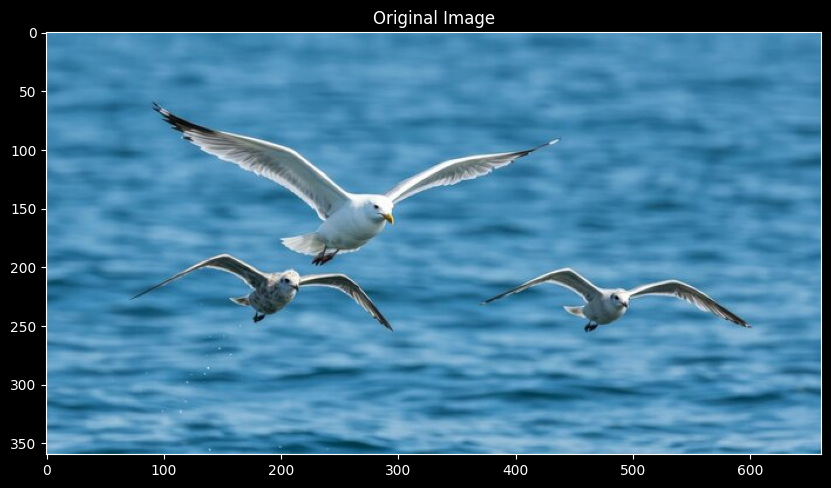

In [10]:
### START CODE HERE ###

image = 'assets/bird.jpg'
img = cv2.imread(image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title('Original Image', color='white')
plt.show()

### END CODE HERE ###

Normalize the image using the mean and standard deviation values from the [VGG16 normalization parameters.](https://pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html)
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/2.png?raw=true)

</details>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1179039301310043..2.6399999999999997].


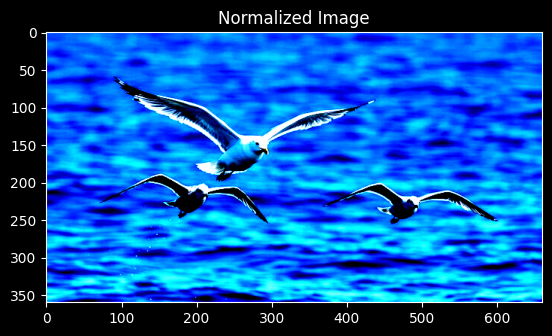

In [11]:
### START CODE HERE ###

# Normalize image using VGG16 normalization parameters
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Convert to float and normalize to [0,1]
img_normalized = img.astype(np.float32) / 255.0

# Apply VGG16 normalization
img_normalized = (img_normalized - mean) / std

plt.imshow(img_normalized)
plt.style.use('dark_background')
plt.title('Normalized Image')
plt.show()

### END CODE HERE ###

Convert the [NumPy image to a PyTorch tensor](https://pytorch.org/docs/stable/torch.html#:~:text=memory%2Dmapped%20file.-,from_numpy,-Creates%20a%20Tensor), ensuring it has the [correct dimensions and data type](https://pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html) for input to the first convolution layer.

In [12]:
### START CODE HERE ###

img_tensor = torch.from_numpy(img_normalized).float()

# from (H, W, C) to (C, H, W)
img_tensor = img_tensor.permute(2, 0, 1)

# Add batch dimension to make it (1, C, H, W)
img_tensor = img_tensor.unsqueeze(0)

print(f"Tensor shape: {img_tensor.shape}")
print(f"Tensor dtype: {img_tensor.dtype}")

### END CODE HERE ###

Tensor shape: torch.Size([1, 3, 360, 661])
Tensor dtype: torch.float32


Complete the function below. <br>
The plot_featuremap function takes a set of feature maps and creates a grid of subplots, each displaying a single feature map. 

In [13]:
### START CODE HERE ###
def plot_featuremap(img, title):
    # Convert tensor to numpy if needed
    if isinstance(img, torch.Tensor):
        img = img.detach().numpy()
    
    # Remove batch dimension if present
    if len(img.shape) == 4:
        img = img.squeeze(0)
    
    # Get number of feature maps
    num_features = img.shape[0]
    
    # Calculate grid size
    cols = 8  # 8 columns as shown in expected output
    rows = (num_features + cols - 1) // cols
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(16, 2*rows))
    fig.suptitle(title, fontsize=16)
    
    # Flatten axes for easy indexing
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    else:
        axes = axes.flatten()
    
    # Plot each feature map
    for i in range(num_features):
        axes[i].imshow(img[i], cmap='gray')
        axes[i].set_title(f'Feature {i}')
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_features, len(axes)):
        axes[i].axis('off')
        
    plt.style.use('dark_background')
    plt.tight_layout()
    plt.show()
### END CODE HERE ###

Pass the image to the first convolutional layer and display the feature map output using your `plot_featuremap()` function.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/3.png?raw=true)
</details>

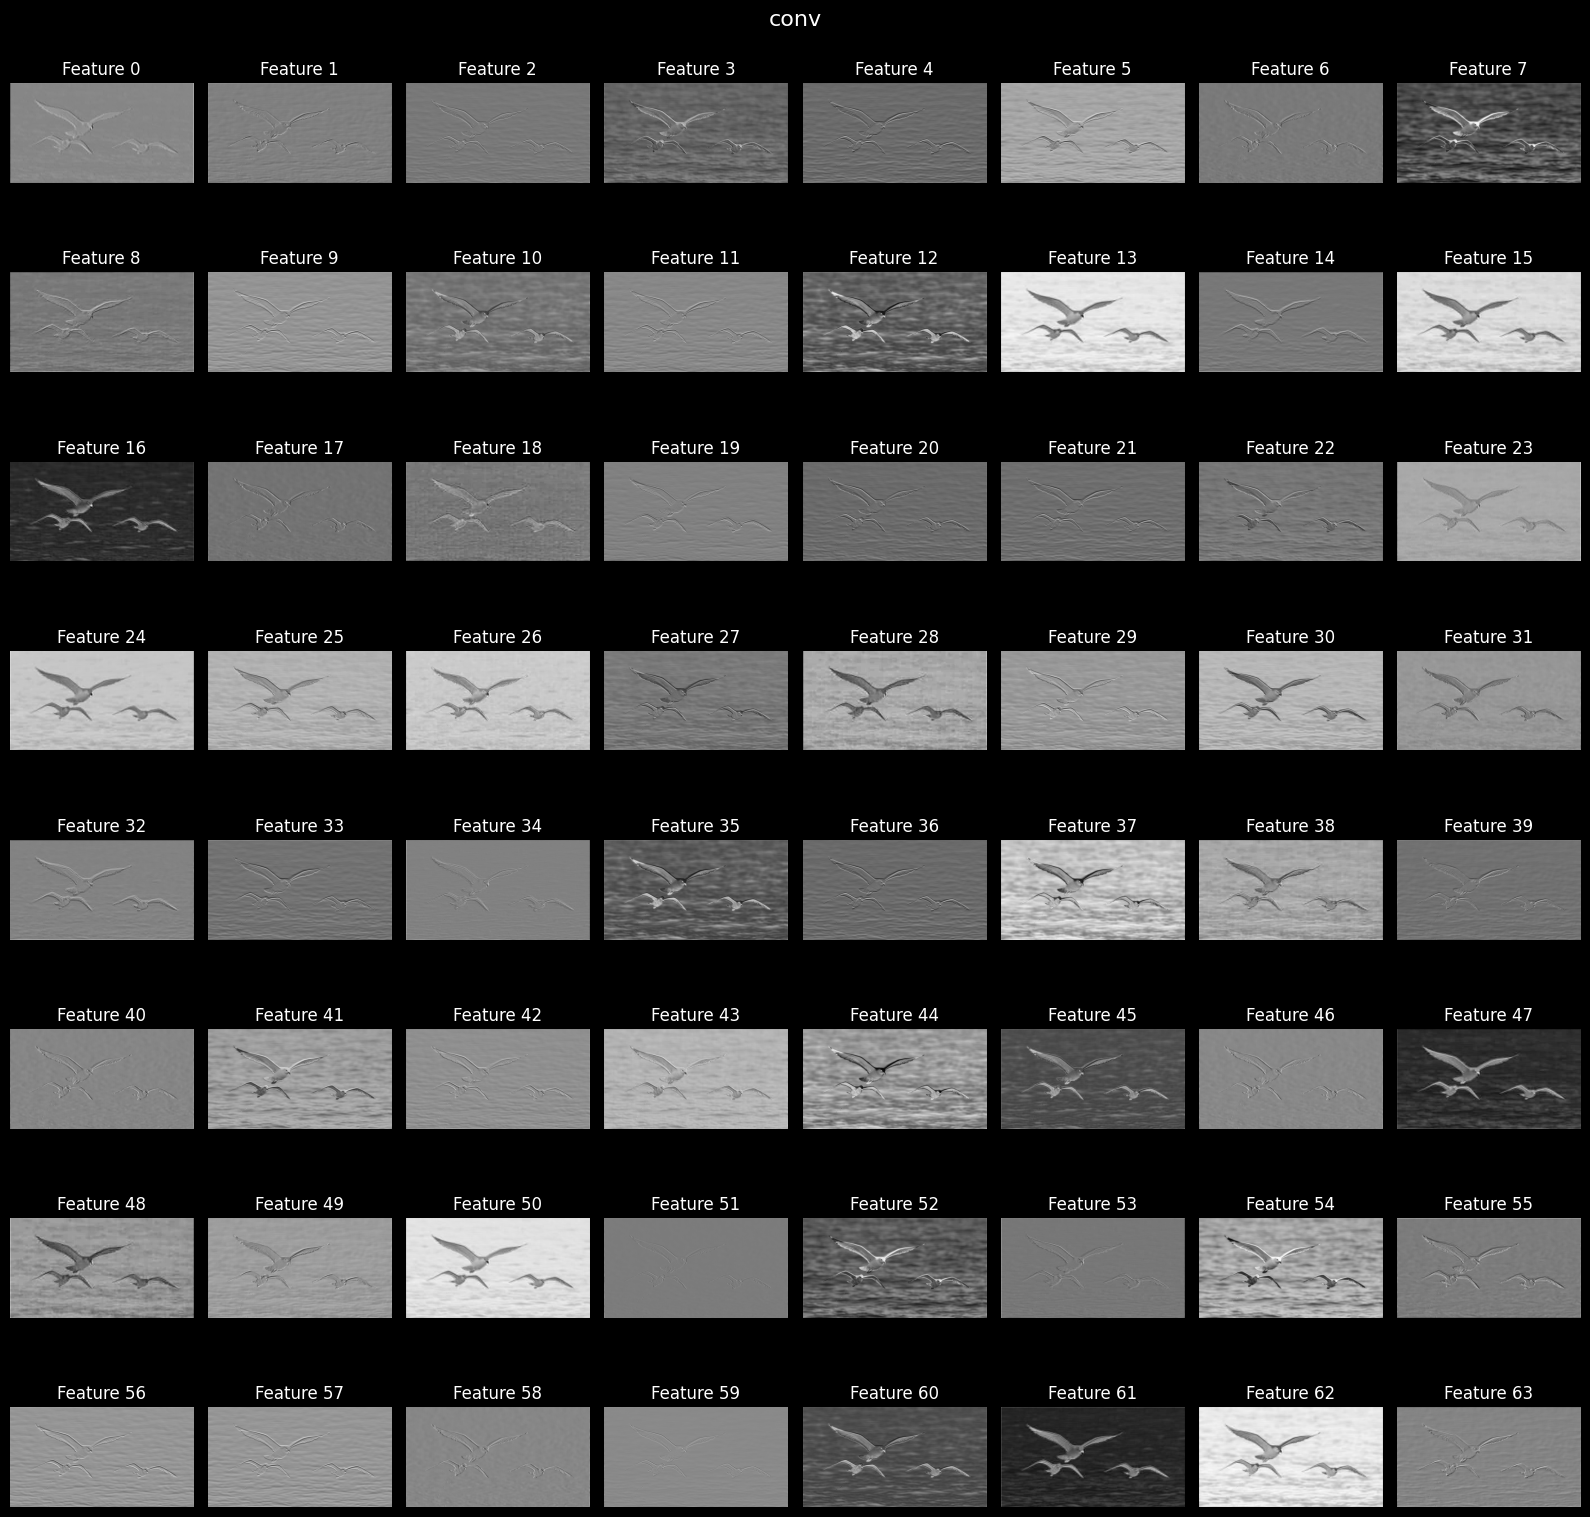

In [14]:
### START CODE HERE ###

# Pass image through first convolutional layer
with torch.no_grad():
    conv_output = first_conv(img_tensor)

# Display the feature maps
plot_featuremap(conv_output, 'conv')

### END CODE HERE ###

Pass the image to the first ReLU layer and display the feature map output using your `plot_featuremap()` function.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/4.png?raw=true)

</details>

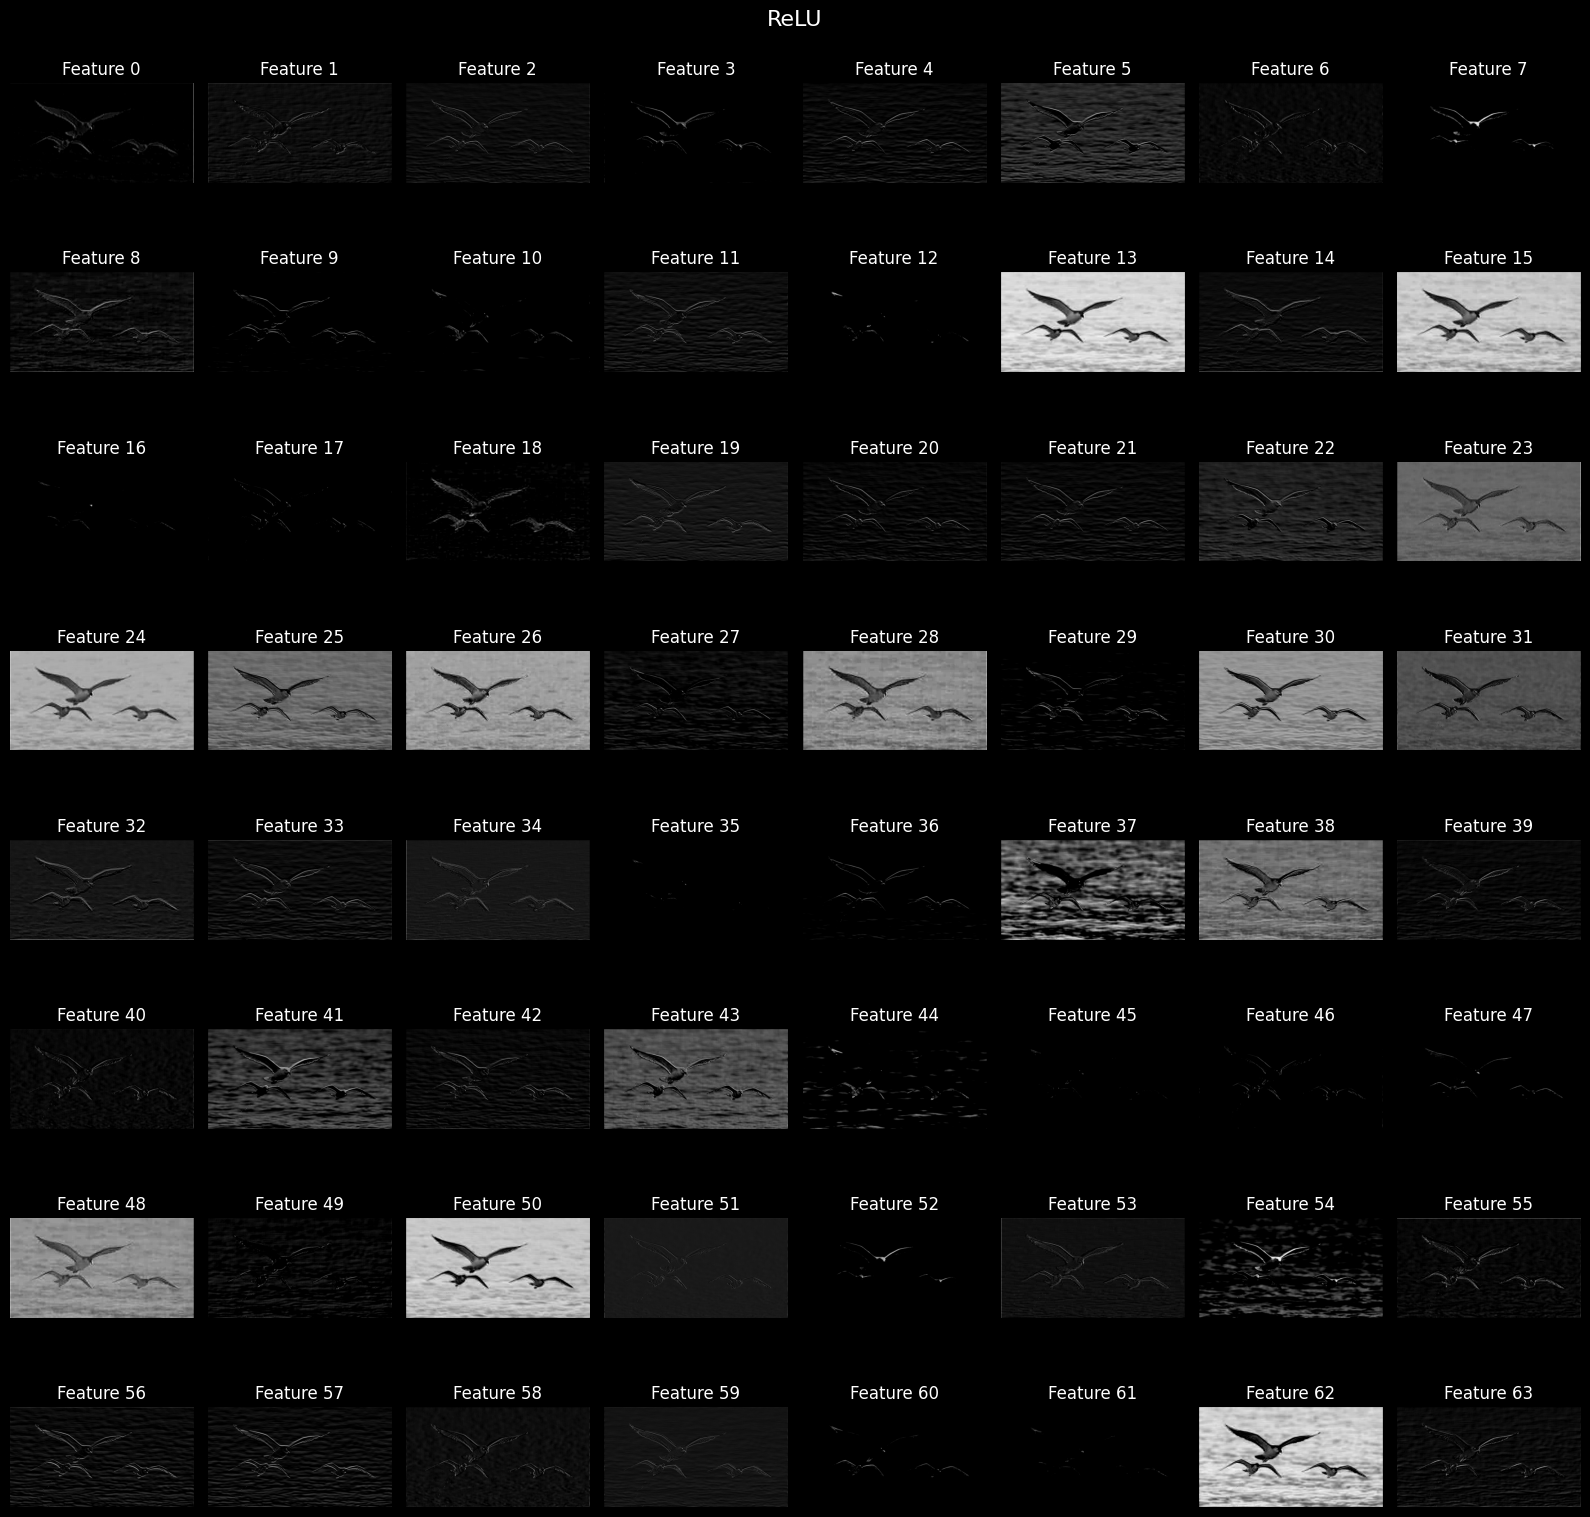

In [15]:
### START CODE HERE ###

# Pass the convolution output through the first ReLU layer
with torch.no_grad():
    relu_output = first_relu(conv_output)

# Display the feature maps after ReLU activation
plot_featuremap(relu_output, 'ReLU')

### END CODE HERE ###

## Convolution 2D from scratch
Complete the function below

In [16]:
### START CODE HERE ###
def convolution2d(img, kernel, padding, stride):
    # Get dimensions
    if len(img.shape) == 3:
        height, width, channels = img.shape
    else:
        channels, height, width = img.shape
        img = img.transpose(1, 2, 0)  # Convert to H, W, C format
    
    kernel_height, kernel_width = kernel.shape[:2]
    
    # Apply padding
    if padding > 0:
        padded_img = np.pad(img, ((padding, padding), (padding, padding), (0, 0)), mode='constant', constant_values=0)
    else:
        padded_img = img
    
    padded_height, padded_width = padded_img.shape[:2]
    
    # Calculate output dimensions
    output_height = (padded_height - kernel_height) // stride + 1
    output_width = (padded_width - kernel_width) // stride + 1
    
    # Initialize output
    output = np.zeros((output_height, output_width))
    
    # Perform convolution
    for i in range(0, output_height * stride, stride):
        for j in range(0, output_width * stride, stride):
            # Extract region of interest
            region = padded_img[i:i+kernel_height, j:j+kernel_width]
            
            # Element-wise multiplication and sum across all channels
            conv_sum = 0
            for c in range(channels):
                conv_sum += np.sum(region[:, :, c] * kernel[:, :, c])
            
            # Store result
            output[i//stride, j//stride] = conv_sum
    
    return output
### END CODE HERE ###

Copy the weights and biases from `vgg16` and then use each kernel perform a 2D convolution using `convolution2d` and display the resulting feature map
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/5.png?raw=true)

</details>

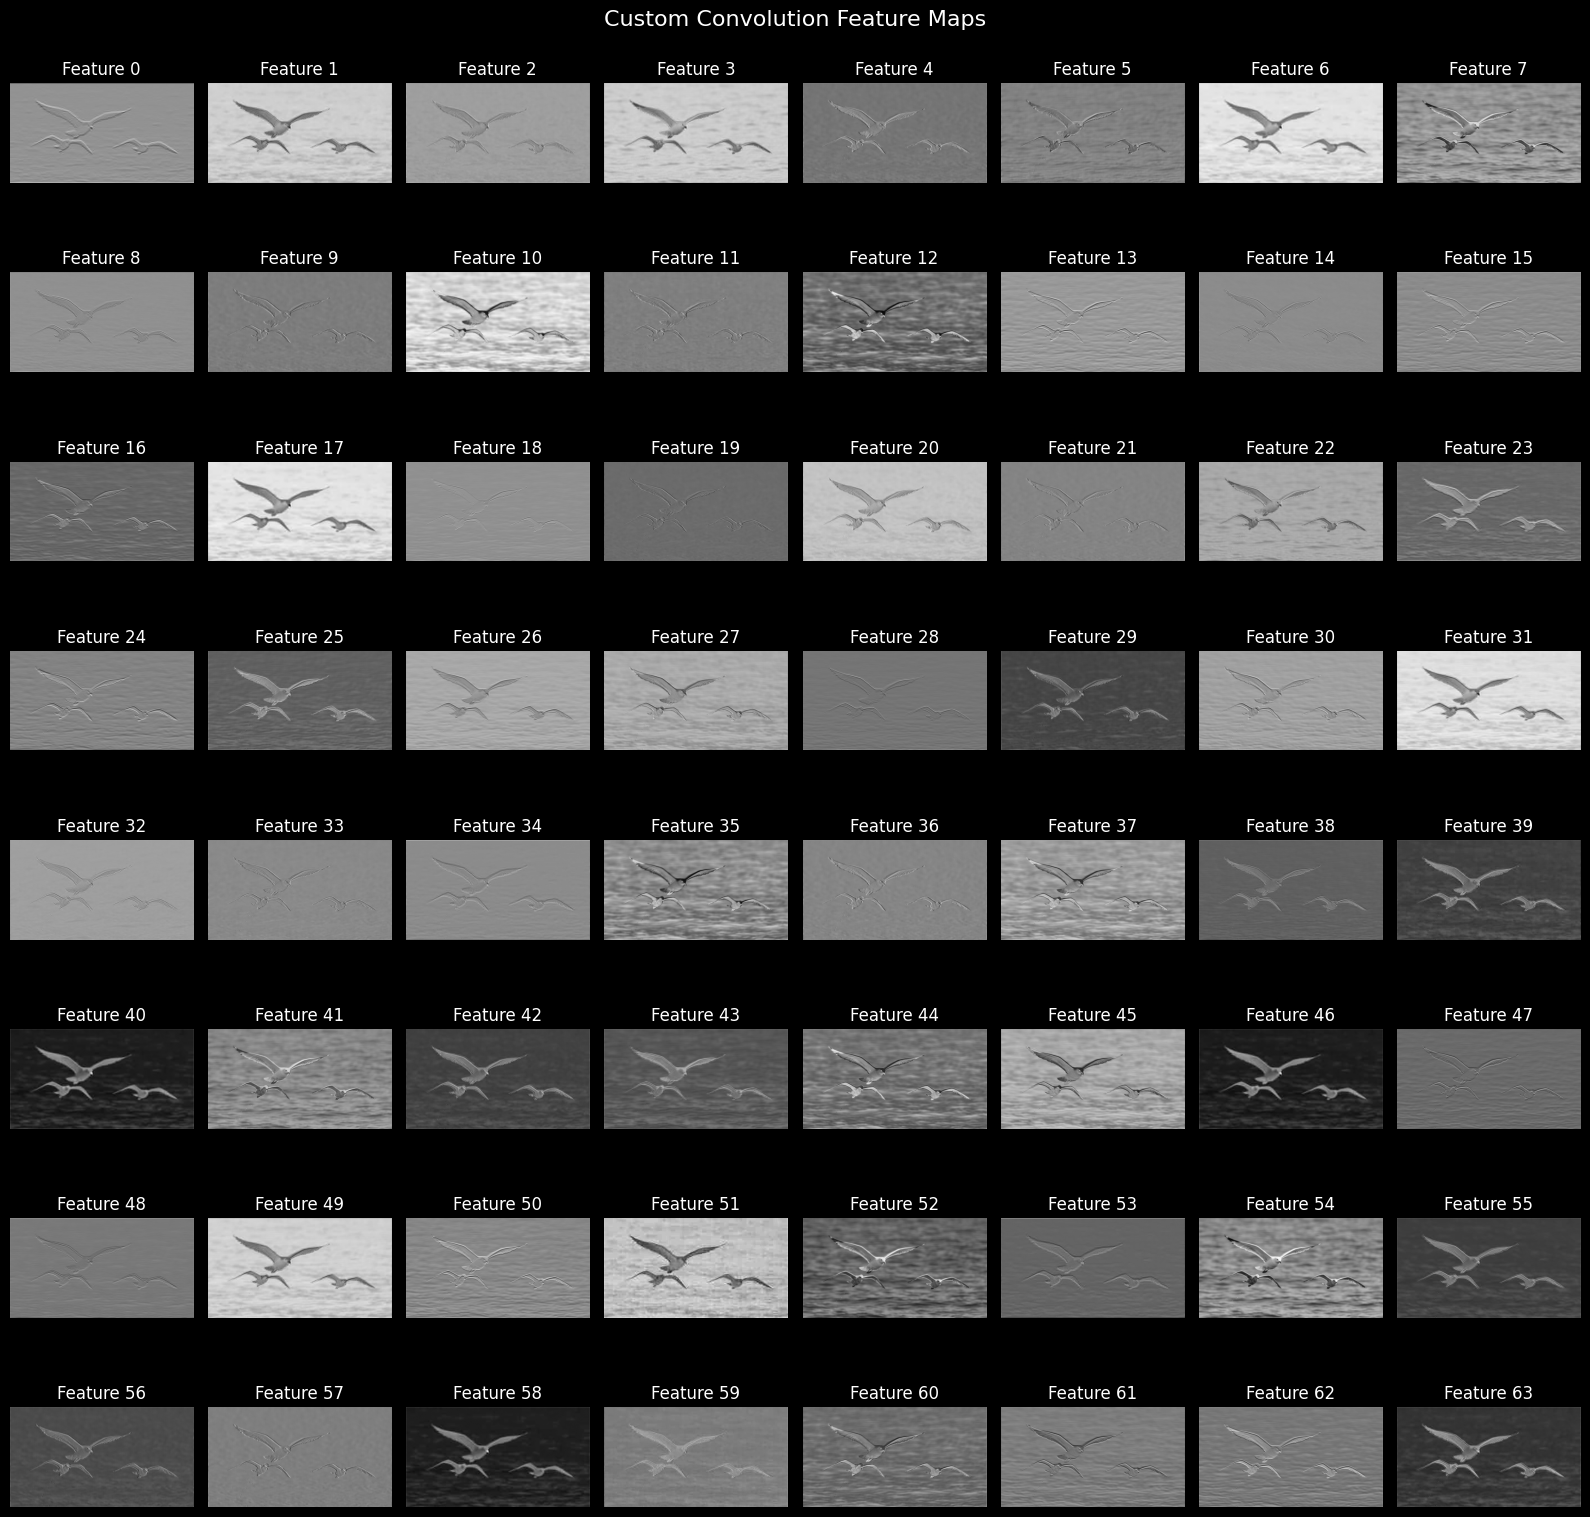

In [17]:
### START CODE HERE ###
   
# Get weights and biases from VGG16 first conv layer
weights = first_conv.weight.data.numpy()
biases = first_conv.bias.data.numpy()

# Initialize output array for all feature maps
num_kernels = weights.shape[0]
feature_maps = []

# Perform convolution with each kernel
for k in range(num_kernels):
    kernel = weights[k]  # Shape: (3, 3, 3)
    bias = biases[k]
    
    # Perform 2D convolution using our custom function
    conv_result = convolution2d(img_normalized, kernel, padding=1, stride=1)
    
    # Add bias
    conv_result += bias
    
    feature_maps.append(conv_result)

# Convert to numpy array and add batch dimension for plotting
feature_maps = np.array(feature_maps)
feature_maps = np.expand_dims(feature_maps, axis=0)

# Display the feature maps
plot_featuremap(feature_maps, 'Custom Convolution Feature Maps')
   
### END CODE HERE ###

After performing the `convolution2d` operation, apply the ReLU activation function to the output. Then, display the resulting feature map.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/6.png?raw=true)

</details>

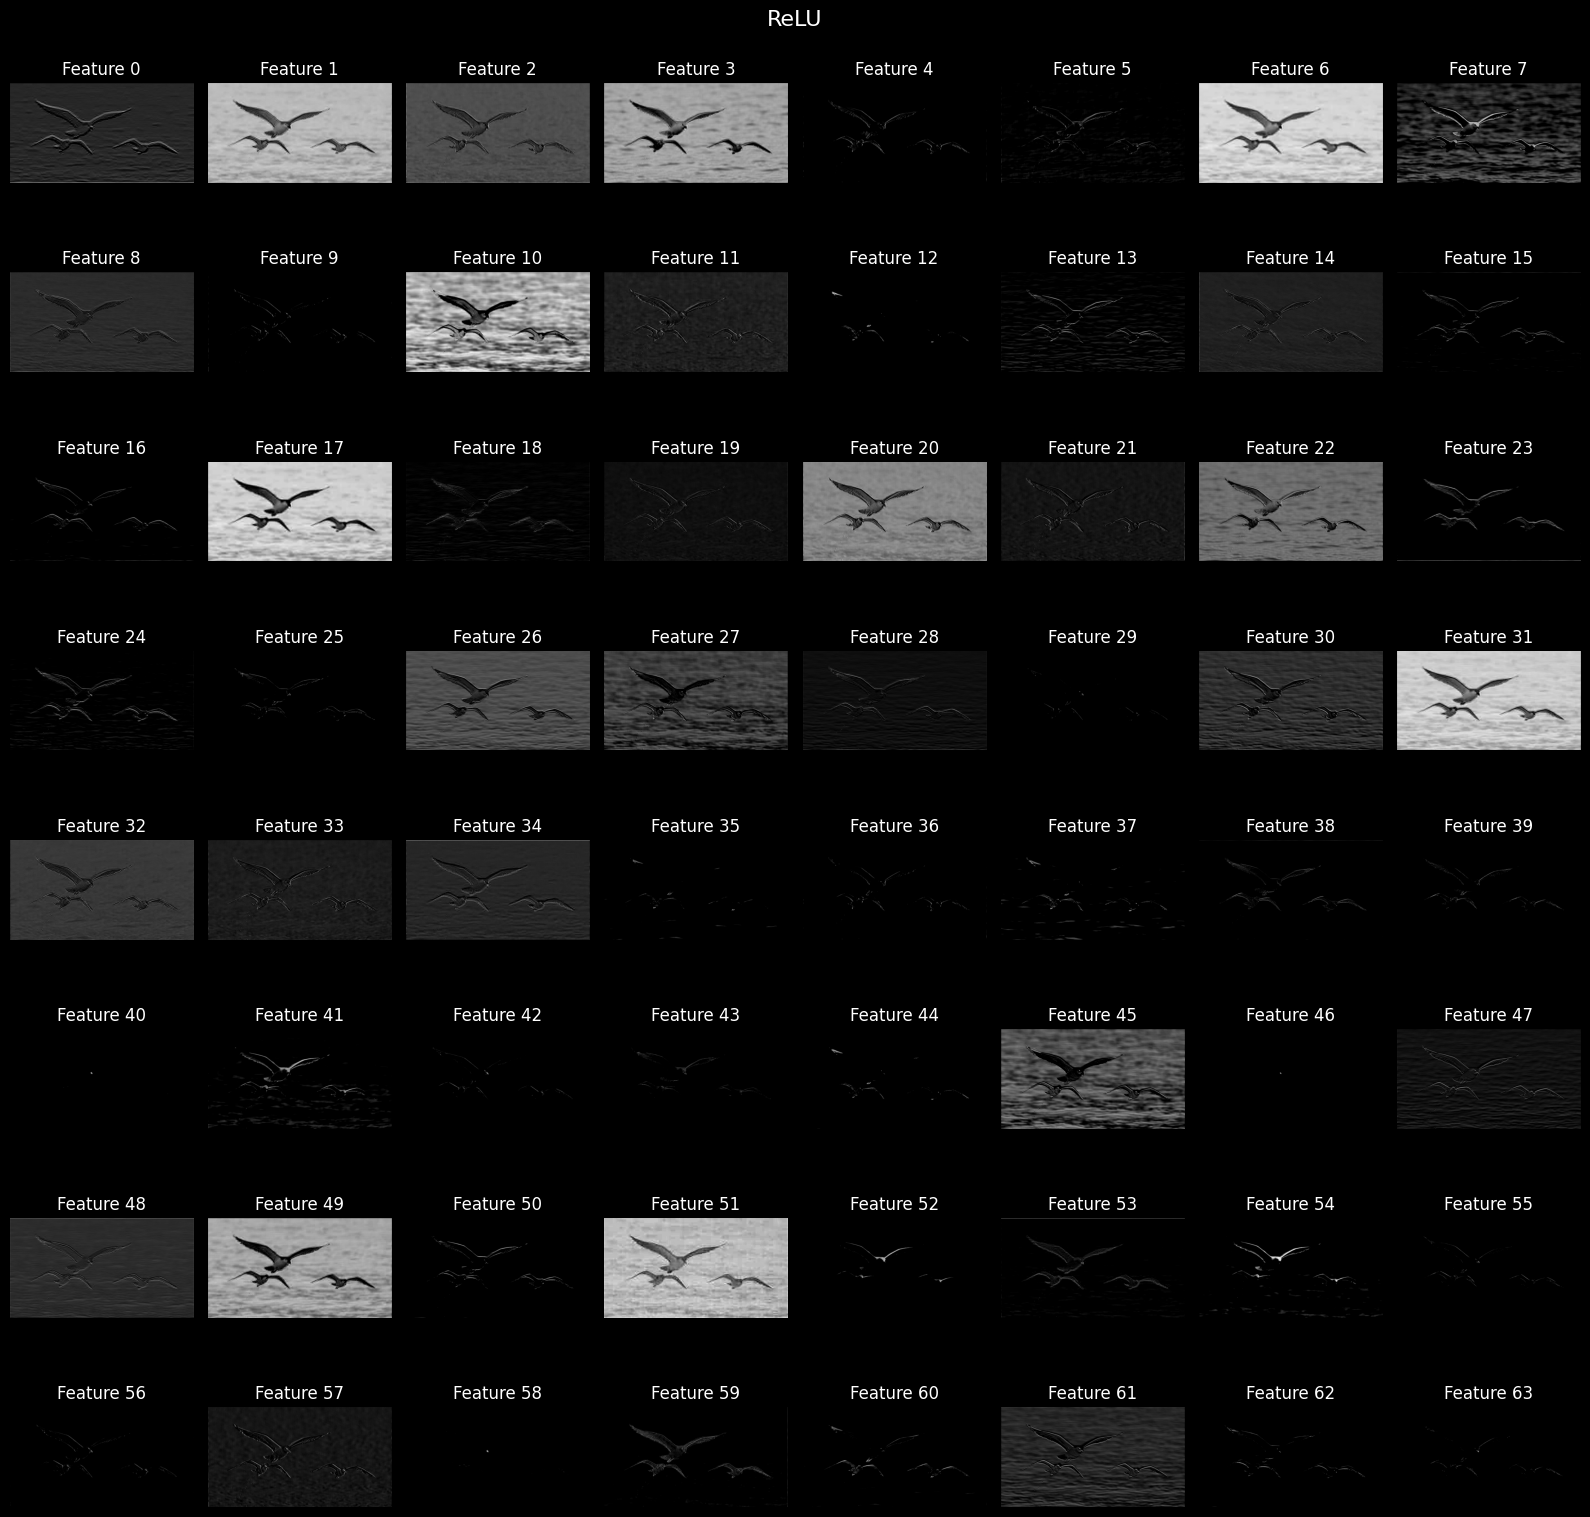

In [18]:
### START CODE HERE ###

# Convert numpy array to torch tensor
feature_maps_tensor = torch.from_numpy(feature_maps).float()

with torch.no_grad():
    scratch_relu = first_relu(feature_maps_tensor)

plot_featuremap(scratch_relu, 'ReLU')

### END CODE HERE ###

---

# Question
1. Show the array of kernel weights used for extracting object color 
and those used for extracting object edge details at least two CNN nodes.
Compare and Discuss how the specific values of these kernel weights influence the CNN's ability 
to detect colors versus edges in images.

**Answer:**
In the first convolutional layer of VGG16, each kernel (or filter) is a 3x3x3 array (for RGB images). Kernels that extract color information tend to have similar values across all three channels, which means they respond strongly to regions of the image with a specific color. For example, a kernel with high positive values in the red channel and near-zero values in green and blue will activate for red regions in the image. In contrast, kernels that extract edge details often have positive and negative values arranged in a way that highlights transitions in intensity, such as a Sobel or Laplacian-like pattern. These edge-detecting kernels may have values like [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]] across one or more channels, making them sensitive to gradients or edges regardless of color. The specific arrangement and magnitude of kernel weights determine whether the filter is more sensitive to color (uniform weights across channels) or to edges (weights that sum to zero and emphasize differences between neighboring pixels). This diversity allows the CNN to detect both color regions and edges in the input image.

2. Why is Matplotlib able to display the output feature map from the convolution layer, even though it contains negative values?

**Answer:**
Matplotlib's `imshow` function can display arrays with any range of values, including negative numbers. When displaying such data, `imshow` automatically maps the minimum and maximum values in the array to the colormap's endpoints. Negative values are simply mapped to one end of the colormap (often dark or blue), while positive values are mapped to the other end (often bright or yellow/red), and zero is mapped to the midpoint. This allows you to visualize the full range of activations, including negative responses, which are common before applying activation functions like ReLU in CNNs.

3. Is there a method faster than traditional 2D convolution in the "Convolution 2D from scratch" section?

**Answer:**
Yes, there are much faster methods than a pure Python or NumPy implementation of 2D convolution. Deep learning frameworks like PyTorch and TensorFlow use highly optimized, compiled libraries (such as cuDNN for NVIDIA GPUs or MKL for CPUs) to perform convolutions. These libraries leverage parallel processing and low-level optimizations, making them orders of magnitude faster than a manual implementation. Additionally, using FFT-based convolution or separable convolution (when applicable) can further speed up the operation. For practical applications, always use the built-in convolution functions provided by these libraries instead of custom Python loops.

# คำถาม
1. แสดงอาร์เรย์ของค่าน้ำหนัก kernel ที่ใช้ในการดึงข้อมูลสีของวัตถุ และที่ใช้ในการดึงรายละเอียดขอบของวัตถุอย่างน้อยสองโหนดใน CNN พร้อมอธิบายว่า ค่าของ kernel เหล่านี้มีผลต่อความสามารถของ CNN ในการตรวจจับสีและขอบของภาพอย่างไร

**คำตอบ:**
ในเลเยอร์คอนโวลูชันแรกของ VGG16 แต่ละ kernel (filter) จะมีขนาด 3x3x3 (สำหรับภาพ RGB) โดย kernel ที่ใช้ดึงข้อมูลสีมักจะมีค่าน้ำหนักที่คล้ายกันในทุก channel ซึ่งจะตอบสนองต่อบริเวณที่มีสีเฉพาะในภาพ เช่น kernel ที่มีค่าสูงใน channel สีแดงและใกล้ศูนย์ใน channel สีเขียวและน้ำเงิน จะตอบสนองต่อบริเวณที่เป็นสีแดง ในขณะที่ kernel ที่ใช้ดึงขอบมักจะมีค่าบวกและลบเรียงตัวกันเพื่อเน้นการเปลี่ยนแปลงของความเข้ม เช่น รูปแบบคล้าย Sobel หรือ Laplacian ซึ่งจะตอบสนองต่อขอบหรือการเปลี่ยนแปลงของพิกเซลโดยไม่สนใจสีโดยตรง การจัดเรียงและขนาดของค่าน้ำหนักใน kernel จะเป็นตัวกำหนดว่า filter นั้นจะไวต่อสี (ค่าน้ำหนักคล้ายกันทุก channel) หรือไวต่อขอบ (ค่าน้ำหนักรวมกันเป็นศูนย์และเน้นความแตกต่างระหว่างพิกเซลข้างเคียง) ความหลากหลายนี้ทำให้ CNN สามารถตรวจจับทั้งบริเวณสีและขอบในภาพได้

2. ทำไม Matplotlib จึงสามารถแสดงผล feature map ที่ได้จาก convolution layer ทั้งที่มีค่าติดลบอยู่ด้วย?

**คำตอบ:**
ฟังก์ชัน `imshow` ของ Matplotlib สามารถแสดงอาร์เรย์ที่มีค่าทุกช่วง แม้จะมีค่าติดลบก็ตาม โดยจะทำการแมปค่าต่ำสุดและสูงสุดในอาร์เรย์ไปยังปลายทั้งสองของ colormap ค่าติดลบจะถูกแมปไปยังด้านมืดหรือสีน้ำเงิน ส่วนค่าบวกจะถูกแมปไปยังด้านสว่างหรือสีเหลือง/แดง และศูนย์จะอยู่ตรงกลางของ colormap วิธีนี้ช่วยให้สามารถมองเห็นการกระตุ้น (activation) ได้ครบทั้งค่าบวกและลบ ซึ่งมักเกิดขึ้นก่อนการใช้ฟังก์ชัน ReLU ใน CNN

3. มีวิธีที่เร็วกว่าการทำ 2D convolution แบบดั้งเดิมในหัวข้อ "Convolution 2D from scratch" หรือไม่?

**คำตอบ:**
มีวิธีที่เร็วกว่าการเขียน convolution ด้วย Python หรือ NumPy โดยตรง เช่น การใช้ไลบรารี deep learning อย่าง PyTorch หรือ TensorFlow ซึ่งใช้ไลบรารีที่ถูกปรับแต่งมาอย่างดี (เช่น cuDNN สำหรับ GPU หรือ MKL สำหรับ CPU) ในการคำนวณ convolution ทำให้เร็วกว่าแบบเขียนเองหลายเท่า นอกจากนี้ยังมีเทคนิค convolution แบบ FFT หรือ separable convolution (ถ้าใช้ได้) ที่ช่วยให้เร็วขึ้นอีก ดังนั้นในการใช้งานจริงควรใช้ฟังก์ชัน convolution ที่มีในไลบรารีเหล่านี้แทนการเขียน loop เอง

In [19]:
# Show kernel arrays for color-sensitive and edge-sensitive filters (at least two of each)
np.set_printoptions(precision=4, suppress=True)

# Get weights from first conv layer: shape (out_channels, in_channels, kh, kw)
weights = first_conv.weight.data.cpu().numpy()
num_kernels = weights.shape[0]

color_scores = []
edge_scores = []

for k in range(num_kernels):
    # Convert kernel to (kh, kw, channels) for easier reasoning
    kernel = np.transpose(weights[k], (1, 2, 0))
    # Per-channel average absolute magnitude
    chan_mags = np.mean(np.abs(kernel), axis=(0, 1))
    # Dominance metric: how much the strongest channel exceeds the others
    max_mag = chan_mags.max()
    other_mag = chan_mags.sum() - max_mag + 1e-8
    dominance = max_mag / other_mag
    color_scores.append((k, dominance, chan_mags, kernel))
    # Edge metric: absolute sum close to zero (zero-sum filters often detect edges) and presence of mixed signs
    abs_sum = np.abs(kernel.sum())
    mixed_sign = (np.any(kernel > 0) and np.any(kernel < 0))
    edge_strength = np.mean(np.abs(kernel))
    edge_scores.append((k, abs_sum, mixed_sign, edge_strength, kernel))

# Select top 2 color detectors by dominance
color_scores_sorted = sorted(color_scores, key=lambda x: x[1], reverse=True)
color_selected = color_scores_sorted[:2]

# Select top 2 edge detectors: prefer small abs_sum and mixed_sign, then larger strength
edge_scores_sorted = sorted(edge_scores, key=lambda x: (x[1], -int(x[2]), -x[3]))
edge_selected = edge_scores_sorted[:2]

print("=== Color-sensitive kernels (top 2 by channel dominance) ===\n")
for idx, dominance, chan_mags, kernel in color_selected:
    print(f"Kernel index: {idx}")
    print(f"Channel mean-abs magnitudes: {chan_mags}")
    print(f"Dominance (max / others): {dominance:.3f}")
    print("Kernel array (kh x kw x channels):")
    print(kernel)
    print("-" * 60)

print("\n=== Edge-sensitive kernels (top 2 by near-zero sum and mixed sign) ===\n")
for idx, abs_sum, mixed_sign, strength, kernel in edge_selected:
    print(f"Kernel index: {idx}")
    print(f"Absolute sum across kernel: {abs_sum:.6f}")
    print(f"Has mixed signs (pos & neg values): {mixed_sign}")
    print(f"Mean absolute value (strength): {strength:.5f}")
    print("Kernel array (kh x kw x channels):")
    print(kernel)
    print("-" * 60)

=== Color-sensitive kernels (top 2 by channel dominance) ===

Kernel index: 58
Channel mean-abs magnitudes: [0.3036 0.5327 0.1686]
Dominance (max / others): 1.128
Kernel array (kh x kw x channels):
[[[ 0.0657  0.3447 -0.0347]
  [ 0.0676  0.3617  0.1935]
  [-0.4305 -0.5835 -0.0203]]

 [[ 0.3337  0.63    0.1287]
  [ 0.4693  0.7424  0.4271]
  [-0.8146 -1.2726 -0.5211]]

 [[ 0.2339  0.191  -0.0495]
  [ 0.2172  0.1137 -0.0213]
  [-0.1002 -0.555  -0.1215]]]
------------------------------------------------------------
Kernel index: 49
Channel mean-abs magnitudes: [0.1556 0.096  0.0423]
Dominance (max / others): 1.125
Kernel array (kh x kw x channels):
[[[-0.2387  0.012  -0.0203]
  [-0.1674  0.0429 -0.0377]
  [ 0.0251  0.052  -0.0086]]

 [[-0.3121 -0.0687 -0.1598]
  [-0.139   0.0661 -0.0531]
  [ 0.1482  0.2071  0.0433]]

 [[-0.1394  0.0619 -0.0226]
  [ 0.0342  0.1883  0.0338]
  [ 0.1964  0.1645  0.0015]]]
------------------------------------------------------------

=== Edge-sensitive kernels 